# Machine Learning Pipeline for IoT Traffic Classification in P4 Switches

## Academic Context

This notebook reproduces the Machine Learning pipeline described in:

> **Xiong, Z., & Zilberman, N.** (2019, November). *Do Switches Dream of Machine Learning? Toward In-Network Classification.* In Proceedings of the 18th ACM Workshop on Hot Topics in Networks (HotNets '19), pp. 25–33. ACM.

applied to the IoT dataset from:

> **Sivanathan, A., Gharakheili, H. H., Loi, F., Radford, A., Wijenayake, C., Vishwanath, A., & Sivaraman, V.** (2018). *Classifying IoT devices in smart environments using network traffic characteristics.* IEEE Transactions on Mobile Computing, 18(8), 1745–1759.

---

## Objective

1. **Understand the problem**: Classify IoT network traffic using only packet header fields.
2. **Run the complete ML pipeline**: From data loading and exploration to Decision Tree training and rule generation.
3. **Connect with the P4 exercise**: The generated rules are used as `table_add` commands in `dt_switch.p4`.

---
## Section 1: Theoretical Background — In-Network Classification with IIsy

### What is IIsy?

**IIsy** (*In-network classification system*) is the system proposed by Xiong & Zilberman (2019) to run Machine Learning algorithms **directly inside the network switch**, without forwarding traffic to an external server for classification.

The core idea is that modern programmable switches (NetFPGA, Intel Tofino, BMv2) expose a Match/Action table pipeline that can be leveraged for ML inference:

```
Packet → [Feature Table 1] → [Feature Table 2] → [Feature Table 3] → [Decision Table] → Action
```

### Why decision trees?

Decision Trees (DT) are especially suitable for this implementation because:

1. **Each tree node is a range comparison**: `feature <= threshold` maps directly to the `range` match type in P4.
2. **Leaves are actions**: Each leaf corresponds to a class (IoT device type) that translates into a forwarding action.
3. **Independent table structure**: Each feature is encoded in a separate table as an interval index; the final decision table combines the indices to determine the class.

### The IoT classification problem

Given a network traffic flow, we want to determine **which type of IoT device** generated it, using only observable packet header fields:

| Feature | Header field | Range |
|---|---|---|
| IP Protocol | `ip.proto` | 0–255 |
| TCP/UDP source port | `tcp.srcPort` | 0–65535 |
| TCP/UDP destination port | `tcp.dstPort` | 0–65535 |

Each IoT device type has **characteristic communication patterns** (e.g., cameras use streaming ports, sensors use DHCP, audio devices use specific cloud service ports), making these three fields sufficient for classification.

### Complete pipeline

```
PCAP captures (Sivanathan et al. 2018)
        ↓
[tshark] Feature extraction → CSV with MAC-based labels
        ↓
[pandas] Dataset loading and exploration
        ↓
[sklearn] Decision Tree training
        ↓
[IIsy get_lineage] Rule extraction → tree.txt
        ↓
[simple_switch_CLI] Rule installation on the BMv2 switch
```

In [20]:
# =============================================================================
# SECTION 0: IMPORTS
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Visualization settings
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13

# Seed for reproducibility
SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")

Libraries loaded successfully.


---
## Section 2: The IoT Dataset

### Origin: Sivanathan et al. (2018)

The dataset comes from real traffic captures on a home network with **28 IoT devices** of different categories. Each packet was captured in PCAP format and features were extracted with tshark.

### Dataset format (UNSW IoT Traffic Traces)

The UNSW site provides each daily trace as a pre-processed CSV (`.csv.zip`), read directly without extraction:

```
Packet ID, TIME, Size, eth.src, eth.dst, IP.src, IP.dst, IP.proto, port.src, port.dst
```

The `eth.src` column (source MAC address) is mapped to an IoT class using `IIsy/trace_processing/replacement_numeric`, then discarded. Only 4 columns are loaded:

| CSV column | DT feature | Description |
|---|---|---|
| `IP.proto` | `ip_proto` | Network protocol (6=TCP, 17=UDP, 1=ICMP) |
| `port.src` | `src_port` | Unified source port (TCP or UDP) |
| `port.dst` | `dst_port` | Unified destination port (TCP or UDP) |
| `eth.src` | `label` | MAC → IoT class (discarded after assignment) |

### Dataset classes

| Class | Device type | Examples |
|---|---|---|
| 0 | Smart-Static (SmartHome) | Nest Cam, Samsung SmartThings Hub |
| 1 | Sensors | Belkin WeMo Motion, SmartThings Sensor |
| 2 | Audio | Amazon Echo, Sonos Play |
| 3 | Video | Philips Hue Bridge, TP-Link Smart Camera |
| 4 | Others | Background traffic, unclassified devices |

### Feature selection for this exercise

The original UNSW CSV has 10 columns. This exercise uses only **3 features**:
`ip_proto`, `src_port`, `dst_port`.

> **Note on feature selection**: This is a **pedagogical constraint**, not a fundamental limitation. The original dataset contains richer information (packet size, IP addresses, timestamps) that could improve accuracy. Any feature set that produces a tree correctly classifiable by P4 range tables is valid. The 3-feature choice is used here because it matches the reference trees in `DecisionTrees2/L3/` and `L4/`, and because these three fields are directly accessible in a P4 parser without additional state.

> The reference trees (`DecisionTrees2/L3/` and `L4/`) were trained with this same dataset and these 3 features. Using an equivalent `max_depth`, the generated trees should be **very similar** to the reference trees.

In [21]:
# =============================================================================
# SECTION 2: LOAD REAL DATASET — UNSW IoT Traffic Traces
# =============================================================================
#
# Dataset: Sivanathan et al. (2018) — 20 days of real IoT traffic
# Source:  https://iotanalytics.unsw.edu.au/iottraces.html  (MIT-0 License)
# Format: CSV with header (10 columns) — read directly from .zip
#
# Used columns:
#   eth.src   → source device MAC address → class label
#   IP.proto  → network protocol (6=TCP, 17=UDP, 1=ICMP)
#   port.src  → unified source port (TCP or UDP)
#   port.dst  → unified destination port (TCP or UDP)

import os
import glob

# Path to the CSV directory (relative to this notebook)
CSV_DIR = os.path.join('..', '..', 'Legacy', 'iottraces_dataset', 'csv')

class_names = ['Smart-Static', 'Sensors', 'Audio', 'Video', 'Others']

# ── MAC → class mapping (source: IIsy/trace_processing/replacement_numeric) ───
# Devices not listed here default to class 4 (Others).
MAC_TO_CLASS = {
    # Class 0 — Smart-Static (hubs and smart plugs)
    'ec:1a:59:7a:02:c5': 0, 'ec:1a:59:83:28:11': 0, 'ec:1a:59:79:f4:89': 0,
    'd0:73:d5:01:83:08': 0, '00:24:e4:44:68:44': 0, '74:6a:89:00:2e:25': 0,
    '74:c6:3b:29:d7:1d': 0, '84:f3:eb:52:42:db': 0,
    # Class 1 — Sensors (motion sensors, alarms, weather stations)
    '70:88:6b:10:0f:c6': 1, '70:ee:50:03:b8:ac': 1,
    '00:24:e4:20:28:c6': 1, '18:b4:30:25:be:e4': 1,
    # Class 2 — Audio (smart speakers, audio streamers)
    'f4:f5:d8:d4:eb:12': 2, '44:65:0d:56:cc:d3': 2,
    '18:b7:9e:02:20:44': 2, '28:c2:dd:ff:a5:2d': 2,
    # Class 3 — Video (IP cameras, Smart TV, baby monitors)
    '00:16:6c:ab:6b:88': 3, '88:4a:ea:31:66:9d': 3, '70:ee:50:18:34:43': 3,
    '7c:70:bc:5d:5e:dc': 3, '30:8c:fb:2f:e4:b2': 3, 'b4:75:0e:ec:e5:a9': 3,
    'f4:f2:6d:93:51:f1': 3, 'e0:76:d0:3f:00:ae': 3, 'f4:f5:d8:8f:0a:3c': 3,
}


def load_all_days(csv_dir):
    """
    Loads all CSV files from the UNSW IoT Traffic Traces dataset.
    Reads directly from .zip — no prior extraction is required.

    For each daily file:
      1. Loads only the 4 necessary columns (usecols) to minimize memory.
      2. Normalizes MAC to lowercase and assigns class (4=Others if MAC unknown).
      3. Discards packets without an IP layer (ARP, etc.).
      4. Fills empty ports with 0 (ICMP packets without TCP/UDP).

    Returns:
        DataFrame with columns: ip_proto (uint8), src_port (uint16),
                                dst_port (uint16), label (uint8)
    """
    zip_files = sorted(glob.glob(os.path.join(csv_dir, '*.csv.zip')))
    if not zip_files:
        raise FileNotFoundError(
            f"No .csv.zip files found in: {os.path.abspath(csv_dir)}\n"
            f"Verify that CSV_DIR points to Legacy/iottraces_dataset/csv/"
        )

    print(f"Loading {len(zip_files)} days from the UNSW IoT Traffic Traces dataset...")
    print(f"  {'File':<22} {'IP Packets':>12}")
    print("  " + "─" * 37)

    frames = []
    for zf in zip_files:
        day = os.path.basename(zf).replace('.csv.zip', '')

        df_day = pd.read_csv(
            zf,
            usecols=['eth.src', 'IP.proto', 'port.src', 'port.dst'],
            dtype={'IP.proto': 'float32', 'port.src': 'float32', 'port.dst': 'float32'},
            low_memory=False
        )

        # Assign class from MAC (normalized to lowercase); unknowns → class 4
        df_day['label'] = (df_day['eth.src'].str.lower()
                                            .map(MAC_TO_CLASS)
                                            .fillna(4)
                                            .astype('uint8'))
        df_day = df_day.drop(columns=['eth.src'])

        # Remove packets without IP layer (ARP, etc.) and adjust types
        df_day = df_day.dropna(subset=['IP.proto'])
        df_day['ip_proto'] = df_day['IP.proto'].astype('uint8')
        df_day['src_port'] = df_day['port.src'].fillna(0).astype('uint16')
        df_day['dst_port'] = df_day['port.dst'].fillna(0).astype('uint16')
        df_day = df_day[['ip_proto', 'src_port', 'dst_port', 'label']]

        frames.append(df_day)
        print(f"  {day:<22} {len(df_day):>12,}")

    df = pd.concat(frames, ignore_index=True)
    mem_mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"  {'─'*37}")
    print(f"  {'Total':<22} {len(df):>12,}")
    print(f"  Memory in RAM: {mem_mb:.0f} MB")
    return df


# === LOAD ALL 20 DAYS OF THE REAL DATASET ===
df = load_all_days(CSV_DIR)

print(f"\nClass distribution:")
print("─" * 55)
for cls, name in enumerate(class_names):
    cnt = (df['label'] == cls).sum()
    pct = cnt / len(df) * 100
    bar = '█' * max(1, int(pct / 2))
    print(f"  Class {cls} ({name:>12}): {cnt:>10,}  ({pct:5.1f}%)  {bar}")

Loading 20 days from the UNSW IoT Traffic Traces dataset...
  File                     IP Packets
  ─────────────────────────────────────
  16-09-23                    802,581
  16-09-24                    667,295
  16-09-25                    407,734
  16-09-26                    449,646
  16-09-27                    416,352
  16-09-28                  1,893,525
  16-09-29                    605,732
  16-09-30                    673,414
  16-10-01                    602,174
  16-10-02                    480,741
  16-10-03                    538,827
  16-10-04                  2,213,498
  16-10-05                  1,490,588
  16-10-06                    595,156
  16-10-07                  1,219,398
  16-10-08                    487,395
  16-10-09                    440,170
  16-10-10                    461,009
  16-10-11                  1,860,140
  16-10-12                  4,755,679
  ─────────────────────────────────────
  Total                    21,061,054
  Memory in RAM: 126 MB


---
## Section 3: Exploratory Data Analysis (EDA)

Before training the model, it is useful to understand the dataset structure:
- What is the range and distribution of each feature?
- Are the classes balanced?
- Do the features show discriminative patterns across device types?

In [22]:
# =============================================================================
# SECTION 3.1: BASIC STATISTICS
# =============================================================================
print("=" * 60)
print("FIRST 10 ROWS OF THE DATASET")
print("=" * 60)
display(df.head(10))

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)
print(f"\nNull values: {df.isnull().sum().sum()}")

FIRST 10 ROWS OF THE DATASET


,ip_proto,src_port,dst_port,label
0,6,40234,5228,2
1,6,40234,5228,2
2,6,443,46330,4
3,6,3063,443,4
4,17,61725,53,3
5,6,5228,40234,4
6,6,443,3063,4
7,6,40234,5228,2
8,17,4500,45966,4
9,17,53,61725,4



DATA TYPES
ip_proto     uint8
src_port    uint16
dst_port    uint16
label        uint8
dtype: object

Null values: 0


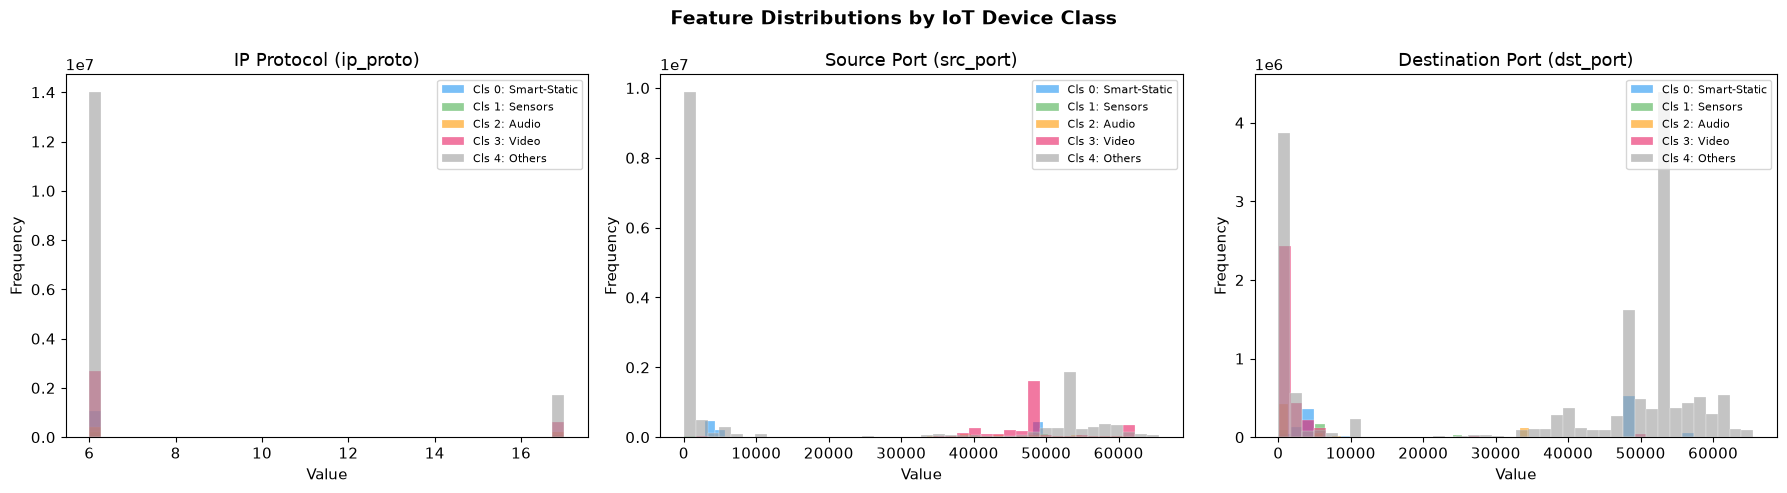

In [23]:
# =============================================================================
# SECTION 3.2: FEATURE DISTRIBUTIONS BY CLASS
# =============================================================================

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9E9E9E']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Feature Distributions by IoT Device Class', fontsize=14, fontweight='bold')

features_to_plot = ['ip_proto', 'src_port', 'dst_port']
feature_labels = ['IP Protocol (ip_proto)', 'Source Port (src_port)', 'Destination Port (dst_port)']

for ax, feat, title in zip(axes, features_to_plot, feature_labels):
    for cls, (name, color) in enumerate(zip(class_names, colors)):
        subset = df[df['label'] == cls][feat]
        ax.hist(subset, bins=40, alpha=0.6, label=f'Cls {cls}: {name}',
                color=color, edgecolor='white', linewidth=0.3)
    ax.set_title(title)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

In [24]:
# =============================================================================
# SECTION 3.3: PROTOCOL DISTRIBUTION PER CLASS
# =============================================================================

print("\nMost frequent IP protocols per class:")
print("=" * 70)
proto_table = df.groupby(['label', 'ip_proto']).size().unstack(fill_value=0)
proto_table.index = [f"Cls {i} ({class_names[i]})" for i in proto_table.index]
proto_names = {1: 'ICMP(1)', 6: 'TCP(6)', 17: 'UDP(17)'}
proto_table.columns = [proto_names.get(c, str(c)) for c in proto_table.columns]
display(proto_table)


Most frequent IP protocols per class:


,TCP(6),UDP(17)
Cls 0 (Smart-Static),1045731,99445
Cls 1 (Sensors),229264,52753
Cls 2 (Audio),405833,202332
Cls 3 (Video),2678993,610002
Cls 4 (Others),14028117,1708584


---
## Section 4: Preprocessing

### Feature selection

The P4 exercise uses exactly **3 features** from the original IIsy tree:

| Feature | Justification |
|---|---|
| `ip_proto` | Differentiates TCP (6), UDP (17), ICMP (1). IoT devices have preferred protocols. |
| `src_port` | IoT devices use specific source port ranges depending on their function. |
| `dst_port` | Services accessed by each device type have well-known destination ports. |

### Why is normalization not needed?

Decision trees are **scale-invariant**: the CART algorithm splits the feature space using learned thresholds from the data, regardless of the absolute magnitude of values. Normalization is not required (unlike SVM or neural networks).

### Train/test split

A stratified 70%/30% split is used to preserve class proportions in both sets.

In [25]:
# =============================================================================
# SECTION 4: PREPROCESSING
# =============================================================================

FEATURE_NAMES = ['ip_proto', 'src_port', 'dst_port']
LABEL_COL = 'label'

X = df[FEATURE_NAMES].values
y = df[LABEL_COL].values

print("Selected features:", FEATURE_NAMES)
print(f"X shape: {X.shape}  (samples × features)")
print(f"y shape: {y.shape}")

# Stratified 70% train / 30% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set:         {X_test.shape[0]} samples")

print("\nClass distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({class_names[cls]}): {cnt}")

print("\nClass distribution in test set:")
unique, counts = np.unique(y_test, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Class {cls} ({class_names[cls]}): {cnt}")

Selected features: ['ip_proto', 'src_port', 'dst_port']
X shape: (21061054, 3)  (samples × features)
y shape: (21061054,)

Training set: 14742737 samples
Test set:         6318317 samples

Class distribution in training set:
  Class 0 (Smart-Static): 801623
  Class 1 (Sensors): 197412
  Class 2 (Audio): 425716
  Class 3 (Video): 2302296
  Class 4 (Others): 11015690

Class distribution in test set:
  Class 0 (Smart-Static): 343553
  Class 1 (Sensors): 84605
  Class 2 (Audio): 182449
  Class 3 (Video): 986699
  Class 4 (Others): 4721011


---
## Section 5: Decision Tree Training

### CART algorithm

scikit-learn implements **CART** (Classification and Regression Trees), which builds the tree greedily:

1. At each node, it tests all possible splits `(feature, threshold)` for the node's samples.
2. It selects the split that **minimizes Gini impurity** in the children.
3. It repeats recursively until `max_depth` or stopping criteria are reached.

**Gini impurity** of a node with class distribution $p_k$:

$$G = 1 - \sum_{k=0}^{K-1} p_k^2$$

A pure node (all samples from the same class) has $G = 0$.

### Choosing max_depth

The `max_depth` parameter controls the trade-off between tree complexity and P4 table size:
- **Depth 3 (L3 exercise)**: Fewer rules → smaller P4 table, slightly lower accuracy.
- **Depth 4 (L4 exercise)**: More rules → higher accuracy but larger P4 table.

In [26]:
# =============================================================================
# SECTION 5.1: max_depth COMPARISON TABLE
# =============================================================================

depths = [2, 3, 4, 5, 6, 8, None]
results = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=SEED)
    clf.fit(X_train, y_train)
    results.append({
        'max_depth': str(d) if d else 'Unlimited',
        'Train Acc.': f"{accuracy_score(y_train, clf.predict(X_train)):.4f}",
        'Test Acc.':  f"{accuracy_score(y_test,  clf.predict(X_test)):.4f}",
        'Leaves':     clf.get_n_leaves(),
        'Nodes':      clf.tree_.node_count
    })

df_results = pd.DataFrame(results)
print("Decision tree depth comparison:")
print("=" * 55)
display(df_results.set_index('max_depth'))
print("\nThe L3 exercise uses max_depth=3; the L4 exercise uses max_depth=4.")

Decision tree depth comparison:


,Train Acc.,Test Acc.,Leaves,Nodes
max_depth,,,,
2,0.8080,0.8081,4,7
3,0.8427,0.8427,8,15
4,0.8865,0.8864,15,29
5,0.9151,0.9151,29,57
6,0.9211,0.9211,51,101
8,0.9385,0.9386,145,289
Unlimited,0.9865,0.9836,64729,129457



The L3 exercise uses max_depth=3; the L4 exercise uses max_depth=4.


In [27]:
# =============================================================================
# SECTION 5.2: TRAINING WITH max_depth=3 (L3 exercise)
# =============================================================================
#
# We use max_depth=3 as in the L3 exercise.
# Equivalent to the reference tree configuration in L3/tree-one.txt
# (trained on real IoT traffic data)

MAX_DEPTH = 3

clf_L3 = DecisionTreeClassifier(
    max_depth=MAX_DEPTH,
    criterion='gini',
    random_state=SEED
)
clf_L3.fit(X_train, y_train)

y_pred_train = clf_L3.predict(X_train)
y_pred_test  = clf_L3.predict(X_test)

print(f"Tree trained with max_depth={MAX_DEPTH}")
print(f"  Training Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"  Test Accuracy:        {accuracy_score(y_test,  y_pred_test):.4f}")
print(f"  Number of leaves:           {clf_L3.get_n_leaves()}")
print(f"  Total number of nodes:   {clf_L3.tree_.node_count}")

print("\n" + "=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)
for feat, imp in zip(FEATURE_NAMES, clf_L3.feature_importances_):
    bar = '█' * int(imp * 40)
    print(f"  {feat:15s}: {imp:.4f}  {bar}")

print("\nInterpretation:")
print("  - Feature importance measures how much each feature reduces Gini impurity.")
print("  - A high value indicates that the feature is highly discriminative.")
print("  - This justifies why src_port and dst_port are good IoT classifiers.")

Tree trained with max_depth=3
  Training Accuracy: 0.8427
  Test Accuracy:        0.8427
  Number of leaves:           8
  Total number of nodes:   15

FEATURE IMPORTANCE
  ip_proto       : 0.0000  
  src_port       : 0.7789  ███████████████████████████████
  dst_port       : 0.2211  ████████

Interpretation:
  - Feature importance measures how much each feature reduces Gini impurity.
  - A high value indicates that the feature is highly discriminative.
  - This justifies why src_port and dst_port are good IoT classifiers.


---
## Section 6: Decision Tree Visualization

The trained tree is shown as a graph with Gini values, sample counts, and class distribution at each node. Colors indicate the dominant class (more saturated = purer node).

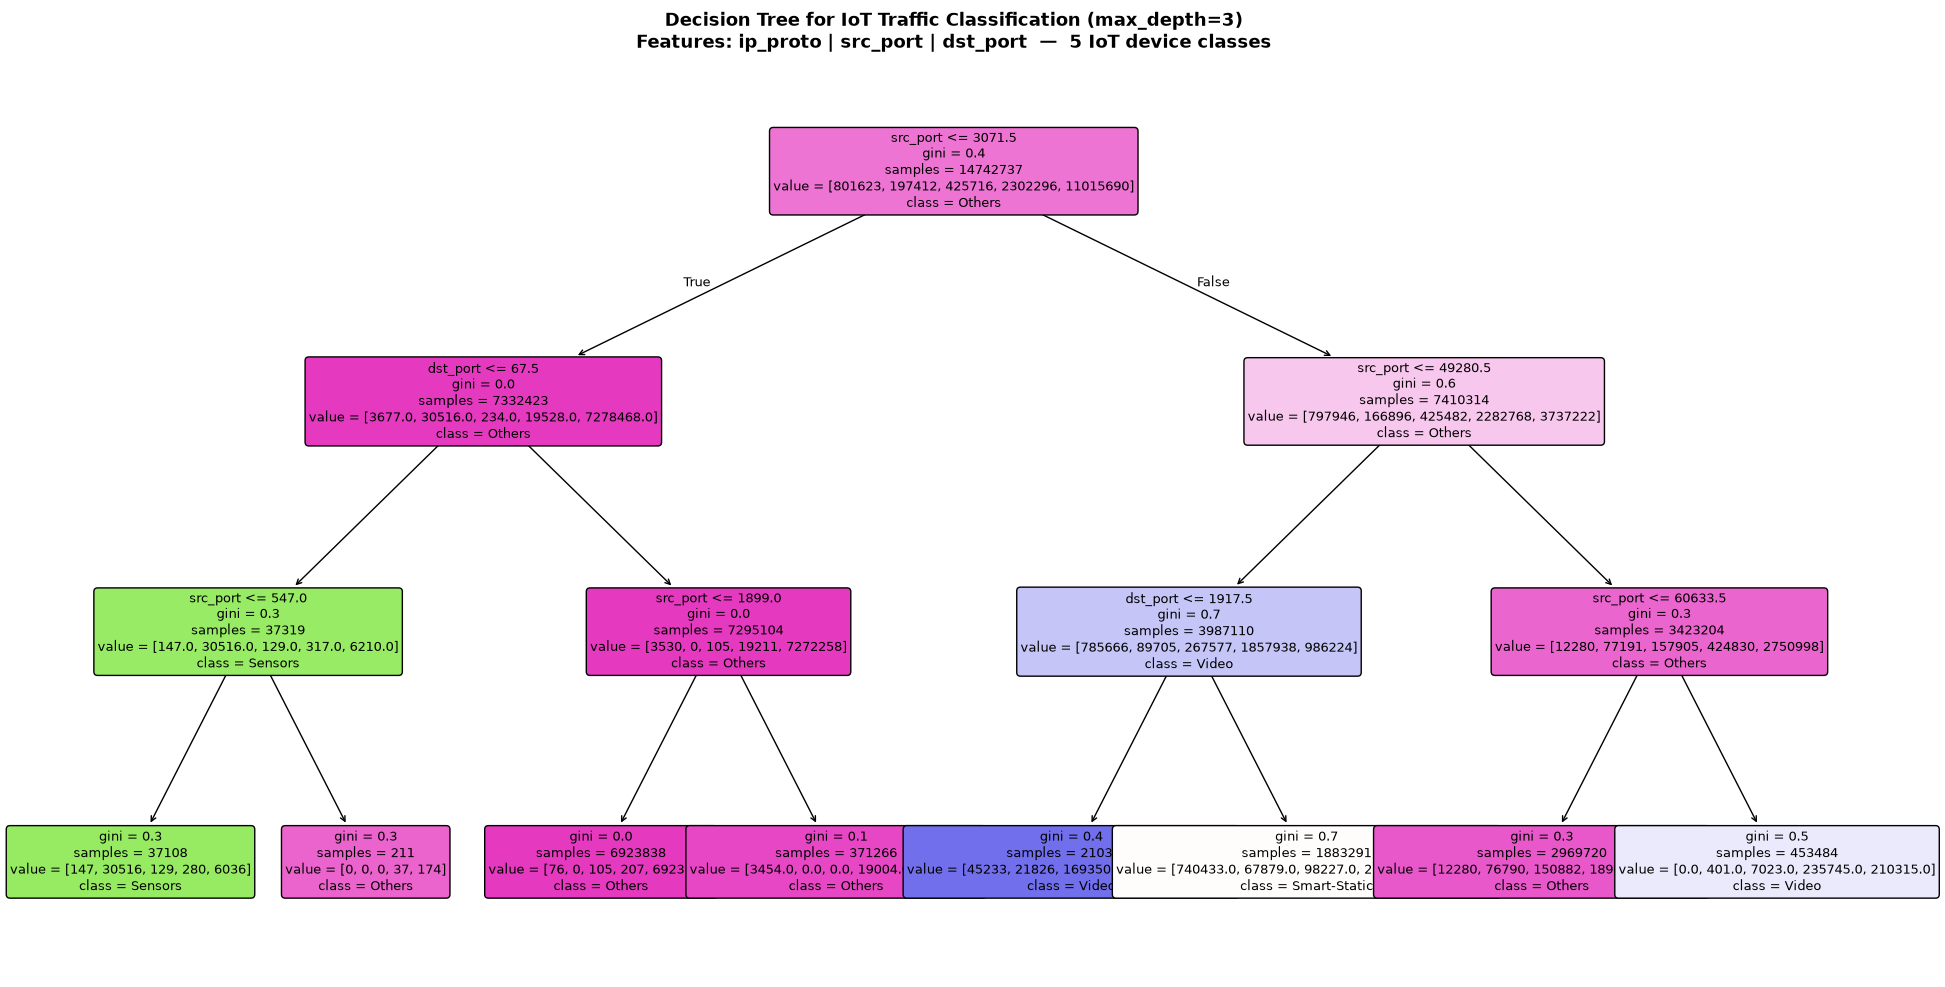


How to read the tree:
  - Each internal node shows: feature <= threshold | gini | samples | values
  - 'values' = class distribution at that node
  - Leaf nodes (terminal boxes) show the predicted class
  - Color saturation indicates node purity


In [29]:
# =============================================================================
# SECTION 6.1: DECISION TREE VISUALIZATION
# =============================================================================

fig, ax = plt.subplots(figsize=(20, 10))

plot_tree(
    clf_L3,
    feature_names=FEATURE_NAMES,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    precision=1
)

ax.set_title(
    f'Decision Tree for IoT Traffic Classification (max_depth={MAX_DEPTH})\n'
    f'Features: ip_proto | src_port | dst_port  —  5 IoT device classes',
    fontsize=13, fontweight='bold'
)


plt.tight_layout()
plt.show()

print("\nHow to read the tree:")
print("  - Each internal node shows: feature <= threshold | gini | samples | values")
print("  - 'values' = class distribution at that node")
print("  - Leaf nodes (terminal boxes) show the predicted class")
print("  - Color saturation indicates node purity")

---
## Section 7: Rule Extraction from the Tree

The IIsy repository includes the `get_lineage` function, which traverses the tree from each **leaf** up to the **root** to build the complete condition for that leaf.

Output format (identical to `L3/tree-one.txt` and `L4/tree-one.txt`):

```
ip_proto = [11];                                    # feature thresholds
src_port = [2949, 5019, 25581, 47939, 49909];
dst_port = [67];
 when src_port<=2949 and dst_port<=67  then 1;      # condition → class
 when src_port<=2949 and dst_port>67   then 4;
 ...
```

Each rule has the form: `when <condition_1> and <condition_2> and ... then <class>`

**Note**: sklearn thresholds are floats (e.g., `2949.5`) representing cut points between integer values. They are truncated to integers in the final representation.

In [31]:
# =============================================================================
# SECTION 7.1: get_lineage FUNCTION (adapted from IIsy/iisy_sw/framework/Machinelearning.py)
# =============================================================================
# Copyright (c) 2019 Zhaoqi Xiong, Noa Zilberman (NetFPGA)
# Adapted for the 3-feature exercise: ip_proto, src_port, dst_port

def get_lineage(clf, feature_names):
    """
    Extracts the decision tree rules in readable format.

    Traverses the tree from each leaf up to the root, building
    the sequence of conditions that lead to that leaf.

    Args:
        clf:          Trained sklearn decision tree.
        feature_names: List of feature names ['ip_proto', 'src_port', 'dst_port'].

    Returns:
        rules:   List of strings with 'when ... then class' rules.
        thresholds_per_feature: Dict feature → list of thresholds (int).
    """
    tree  = clf.tree_
    left  = tree.children_left     # Left child index of each node (-1 if leaf)
    right = tree.children_right    # Right child index of each node
    thr   = tree.threshold          # Split threshold at each node
    feats = [feature_names[i] for i in tree.feature]  # Feature of each node
    value = tree.value              # Class distribution [n_nodes, 1, n_classes]

    # IDs of leaf nodes (children_left == -1 in sklearn)
    leaf_ids = np.argwhere(left == -1)[:, 0]

    def recurse(node, lineage=None):
        """Walks up from 'node' to the root, collecting the path."""
        if lineage is None:
            lineage = [node]  # Start with the current leaf
        if node in left:
            parent = int(np.where(left == node)[0][0])   # [0]=array from tuple, [0]=scalar index
            side = 'l'  # Came via the left branch (<=)
        else:
            parent = int(np.where(right == node)[0][0])  # same fix
            side = 'r'  # Came via the right branch (>)
        lineage.append((parent, side, thr[parent], feats[parent]))
        if parent == 0:
            lineage.reverse()  # From root to leaf
            return lineage
        return recurse(parent, lineage)

    rules = []
    thresholds_per_feature = {f: [] for f in feature_names}

    for leaf in leaf_ids:
        path  = recurse(leaf)
        clause = ' when '

        for node_info in path:
            # Leaves are simple integers (no tuple), internal nodes are 4-tuples
            if not isinstance(node_info, tuple):
                continue
            parent, side, threshold, feature = node_info

            sign = '<=' if side == 'l' else '>'
            # Show threshold as integer (sklearn uses 11.5, 2949.5, etc.)
            clause += f"{feature}{sign}{int(threshold)} and "

            # Collect thresholds per feature
            if threshold > -2:  # -2 is the value for leaf nodes in sklearn
                thresholds_per_feature[feature].append(int(threshold))

        # Predicted class of the leaf: index of the maximum value
        predicted_class = int(np.argmax(value[leaf][0]))

        # Remove the final ' and ' and add the class
        clause = clause.rstrip(' and ') + f' then {predicted_class}'
        rules.append(clause)

    # Deduplicate and sort thresholds
    for f in feature_names:
        thresholds_per_feature[f] = sorted(set(thresholds_per_feature[f]))

    return rules, thresholds_per_feature


# Extract rules from the L3 tree
rules_L3, thresholds_L3 = get_lineage(clf_L3, FEATURE_NAMES)

print(f"Tree L3 (max_depth=3): {len(rules_L3)} extracted rules")
print("\nThresholds per feature:")
for feat in FEATURE_NAMES:
    print(f"  {feat} = {thresholds_L3[feat]}")

Tree L3 (max_depth=3): 8 extracted rules

Thresholds per feature:
  ip_proto = []
  src_port = [547, 1899, 3071, 49280, 60633]
  dst_port = [67, 1917]


In [32]:
# =============================================================================
# SECTION 7.2: GENERATE TREE FILE (L3/tree-one.txt format)
# =============================================================================

def generate_tree_file_content(rules, thresholds_per_feature, feature_names):
    """
    Generates the tree file content in IIsy / DT exercise format.

    Format:
        ip_proto = [11];                        # thresholds for each feature
        src_port = [2949, 5019, ...];
        dst_port = [67];
         when src_port<=2949 and dst_port<=67  then 1;
         ...
    """
    lines = []
    for feat in feature_names:
        thrs = thresholds_per_feature[feat]
        lines.append(f"{feat} = {thrs};")
    lines.append('')
    for rule in rules:
        lines.append(rule + ";")
    return '\n'.join(lines)


tree_content_L3 = generate_tree_file_content(rules_L3, thresholds_L3, FEATURE_NAMES)

print("\n" + "=" * 60)
print("GENERATED TREE (tree.txt format — max_depth=3)")
print("=" * 60)
print(tree_content_L3)

# Save to file
with open('tree_L3_generado.txt', 'w') as f:
    f.write(tree_content_L3)

print(f"\nFile saved: tree_L3_generado.txt")


GENERATED TREE (tree.txt format — max_depth=3)
ip_proto = [];
src_port = [547, 1899, 3071, 49280, 60633];
dst_port = [67, 1917];

 when src_port<=3071 and dst_port<=67 and src_port<=547 then 1;
 when src_port<=3071 and dst_port<=67 and src_port>547 then 4;
 when src_port<=3071 and dst_port>67 and src_port<=1899 then 4;
 when src_port<=3071 and dst_port>67 and src_port>1899 then 4;
 when src_port>3071 and src_port<=49280 and dst_port<=1917 then 3;
 when src_port>3071 and src_port<=49280 and dst_port>1917 then 0;
 when src_port>3071 and src_port>49280 and src_port<=60633 then 4;
 when src_port>3071 and src_port>49280 and src_port>60633 then 3;

File saved: tree_L3_generado.txt


---
## Section 8: Classifier Evaluation

The model is evaluated with standard classification metrics:

- **Accuracy**: Proportion of correct predictions overall.
- **Precision** (per class): Of all predictions for class $k$, how many are actually that class?
- **Recall** (per class): Of all true examples of class $k$, how many are correctly predicted?
- **F1-Score**: Harmonic mean of precision and recall.
- **Confusion matrix**: Visualizes classification errors between classes.

In [ ]:
# =============================================================================
# SECTION 8.1: EVALUATION METRICS
# =============================================================================

print("=" * 70)
print(f"DECISION TREE EVALUATION (max_depth={MAX_DEPTH})")
print("=" * 70)

print(f"\n► Training accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"► Test accuracy:     {accuracy_score(y_test,  y_pred_test):.4f}")

print("\n► Classification report (test set):")
print(classification_report(
    y_test, y_pred_test,
    target_names=[f'Cls {i}: {class_names[i]}' for i in range(5)]
))

DECISION TREE EVALUATION (max_depth=3)

► Training accuracy: 0.8427
► Test accuracy:     0.8427

► Classification report (test set):
                     precision    recall  f1-score   support

Cls 0: Smart-Static       0.39      0.92      0.55    343553
     Cls 1: Sensors       0.82      0.16      0.26     84605
       Cls 2: Audio       0.00      0.00      0.00    182449
       Cls 3: Video       0.72      0.80      0.76    986699
      Cls 4: Others       0.96      0.89      0.92   4721011

           accuracy                           0.84   6318317
          macro avg       0.58      0.55      0.50   6318317
       weighted avg       0.86      0.84      0.84   6318317



In [ ]:
# =============================================================================
# SECTION 8.3: L4 TREE (max_depth=4) — For the advanced exercise
# =============================================================================

clf_L4 = DecisionTreeClassifier(max_depth=4, random_state=SEED)
clf_L4.fit(X_train, y_train)

y_pred_L4 = clf_L4.predict(X_test)

print("Tree L4 (max_depth=4):")
print(f"  Test accuracy: {accuracy_score(y_test, y_pred_L4):.4f}")
print(f"  Number of leaves:    {clf_L4.get_n_leaves()}")

rules_L4, thresholds_L4 = get_lineage(clf_L4, FEATURE_NAMES)
tree_content_L4 = generate_tree_file_content(rules_L4, thresholds_L4, FEATURE_NAMES)

print(f"\nGenerated L4 tree ({len(rules_L4)} rules):")
print("=" * 60)
print(tree_content_L4)

with open('tree_L4_generado.txt', 'w') as f:
    f.write(tree_content_L4)
print("\nFile saved: tree_L4_generado.txt")

print("\n" + "=" * 60)
print("REFERENCE TREE L4/tree-one.txt:")
print("=" * 60)
print("""ip_proto = [11];
src_port = [2910, 5019, 25581, 47939, 48920, 49907, 49909, 60696];
dst_port = [60, 67, 283, 283, 3852, 46265];
 when src_port<=25581 and src_port<=2910 and dst_port<=67 and dst_port<=60  then 4;
 when src_port<=25581 and src_port<=2910 and dst_port<=67 and dst_port>60  then 1;
 when src_port<=25581 and src_port<=2910 and dst_port>67 and ip_proto<=11  then 4;
 when src_port<=25581 and src_port<=2910 and dst_port>67 and ip_proto>11  then 4;
 when src_port<=25581 and src_port>2910 and src_port<=5019 ...""")

Tree L4 (max_depth=4):
  Test accuracy: 0.8864
  Number of leaves:    15

Generated L4 tree (15 rules):
ip_proto = [];
src_port = [547, 1221, 1899, 1900, 3071, 4999, 38034, 49280, 49908, 60633, 60757];
dst_port = [67, 130, 1917];

 when src_port<=3071 and dst_port<=67 and src_port<=547 then 1;
 when src_port<=3071 and dst_port<=67 and src_port>547 and src_port<=1221 then 4;
 when src_port<=3071 and dst_port<=67 and src_port>547 and src_port>1221 then 4;
 when src_port<=3071 and dst_port>67 and src_port<=1899 and dst_port<=130 then 4;
 when src_port<=3071 and dst_port>67 and src_port<=1899 and dst_port>130 then 4;
 when src_port<=3071 and dst_port>67 and src_port>1899 and src_port<=1900 then 3;
 when src_port<=3071 and dst_port>67 and src_port>1899 and src_port>1900 then 4;
 when src_port>3071 and src_port<=49280 and dst_port<=1917 and src_port<=38034 then 4;
 when src_port>3071 and src_port<=49280 and dst_port<=1917 and src_port>38034 then 3;
 when src_port>3071 and src_port<=49280 and

### Referencias

1. Xiong, Z., & Zilberman, N. (2019). *Do Switches Dream of Machine Learning?* ACM HotNets '19.
2. Sivanathan et al. (2018). *Classifying IoT devices in smart environments using network traffic characteristics.* IEEE TMC.
3. Repositorio IIsy: https://github.com/noa-zilberman/iisy
4. scikit-learn DecisionTreeClassifier: https://scikit-learn.org/stable/modules/tree.html
5. BMv2 simple_switch CLI: https://github.com/p4lang/behavioral-model/blob/main/docs/runtime_CLI.md